In [1]:
import torch
from torch import nn
from torch.utils.data import random_split, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
import os
import pandas as pd
from torch.utils.data import Dataset
import sklearn
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor, Lambda


import matplotlib.pyplot as plt

#### **Put data into a database**

In [19]:

class CustomDataset(Dataset):
    def __init__(self, labels, data, dir, transform=None, target_transform=None):
        self.labels = labels
        self.data = data
        self.dir = dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        data = self.data[idx]
        label = self.labels[idx]
        if self.transform:
            data = self.transform(data)
        if self.target_transform:
            label = self.target_transform(label)
                    
        data = torch.from_numpy(data).type(torch.float)
        
        return data, label

In [77]:
# Create the dataset
data_dir = 'data.csv'
labels_file = 'data_labels.csv'

x_data  = np.loadtxt('data.csv', delimiter=',', dtype=float, skiprows = 1)
y_data  = np.loadtxt('data_labels.csv', delimiter=',', dtype=float, skiprows = 1).astype(np.int64)

#Feature transform: log the x-data
x_data[x_data <= 0] = 1e-4 #replace 0s by small numbers so log doesn't go to inf
x_data = np.log10(x_data)

print(np.shape(x_data), np.shape(y_data))

X_train, X_test, y_train, y_test = train_test_split(x_data.T, y_data, test_size=0.20, stratify = y_data, random_state=42)

# Define the transform 
transform = None
target_transform = Lambda(lambda y: torch.zeros(3, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

# Create separate datasets for train and test
train_dataset = CustomDataset(dir=data_dir, labels = y_train, data = X_train, transform=transform, target_transform = target_transform)
test_dataset = CustomDataset(dir=data_dir, labels = y_test, data = X_test, transform=transform, target_transform = None)
#
# print(train_dataset)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=True)
#TODO: Think about batching

for batch_data, batch_labels in train_dataloader:
    print("Batch data shape:", batch_data.shape)   # Correct way to check shape
    print("Batch labels shape:", batch_labels.shape)

#TODO: TRANSORM LABELS TO ONE HOT ENCODERS


(2, 296) (296,)
Batch data shape: torch.Size([128, 2])
Batch labels shape: torch.Size([128, 3])
Batch data shape: torch.Size([108, 2])
Batch labels shape: torch.Size([108, 3])


### **Build Neural Network**

In [78]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(2, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 3),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [82]:
model = NeuralNetwork()
print(model)
model = model.float()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)

        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            # X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            print(pred.shape, y.shape)
            correct += (pred.argmax(dim = 1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return test_loss



NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=3, bias=True)
  )
)


In [83]:
epochs = 2000
loss_history = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    loss = test(test_dataloader, model, loss_fn)

    loss_history.append(loss)
print("Done!")

Epoch 1
-------------------------------
loss: 1.159958  [  128/  236]
torch.Size([60, 3]) torch.Size([60])
Test Error: 
 Accuracy: 43.3%, Avg loss: 1.065825 

Epoch 2
-------------------------------
loss: 1.059280  [  128/  236]
torch.Size([60, 3]) torch.Size([60])
Test Error: 
 Accuracy: 51.7%, Avg loss: 1.015448 

Epoch 3
-------------------------------
loss: 1.036884  [  128/  236]
torch.Size([60, 3]) torch.Size([60])
Test Error: 
 Accuracy: 50.0%, Avg loss: 0.984671 

Epoch 4
-------------------------------
loss: 1.023991  [  128/  236]
torch.Size([60, 3]) torch.Size([60])
Test Error: 
 Accuracy: 53.3%, Avg loss: 0.958043 

Epoch 5
-------------------------------
loss: 0.961265  [  128/  236]
torch.Size([60, 3]) torch.Size([60])
Test Error: 
 Accuracy: 63.3%, Avg loss: 0.936340 

Epoch 6
-------------------------------
loss: 0.940527  [  128/  236]
torch.Size([60, 3]) torch.Size([60])
Test Error: 
 Accuracy: 66.7%, Avg loss: 0.916358 

Epoch 7
-------------------------------
loss: 

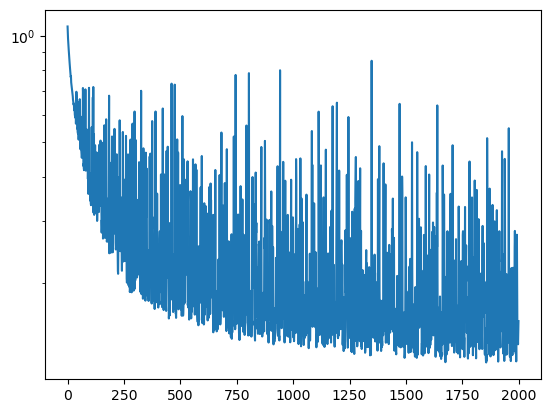

In [84]:
plt.plot(loss_history)
plt.yscale('log')


In [63]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


In [85]:

train_dataset.data = torch.from_numpy(train_dataset.data).type(torch.float)
train_dataset.labels = torch.from_numpy(train_dataset.labels).type(torch.float)
test_dataset.data = torch.from_numpy(test_dataset.data).type(torch.float)
test_dataset.labels = torch.from_numpy(test_dataset.labels).type(torch.float)

if isinstance(train_dataset.data, np.ndarray):
    print("X is a NumPy array")


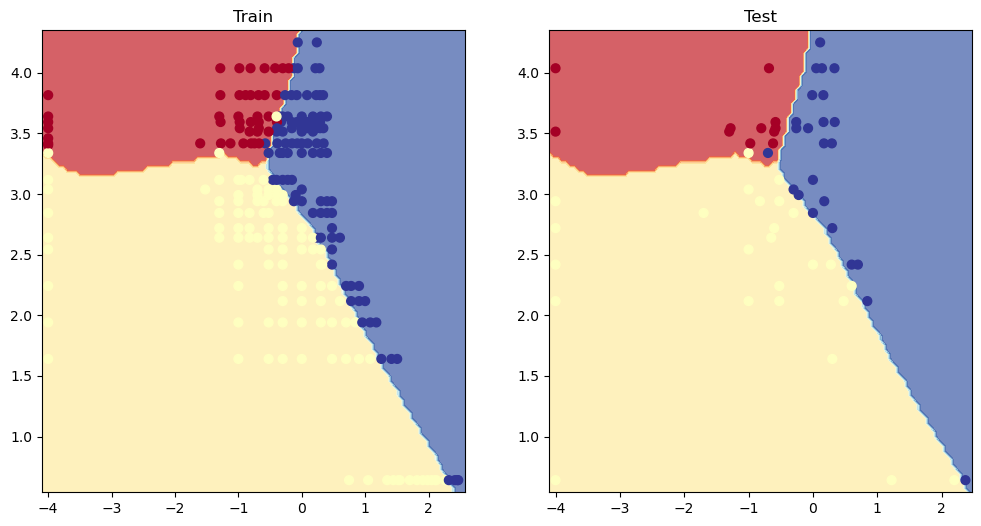

In [86]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")

plot_decision_boundary(model, train_dataset.data, train_dataset.labels)
plt.subplot(1, 2, 2)
plt.title("Test")

plot_decision_boundary(model, test_dataset.data, test_dataset.labels)